# BEE 4750 Lab 2: Monte Carlo

**Name**: Regina Velasco

**ID**: rv297

> **Due Date**
>
> Thursday, 10/02/25, 9:00pm

## Setup

The following code should go at the top of most Julia scripts; it will
load the local package environment and install any needed packages. You
will see this often and shouldn’t need to touch it.

In [64]:
import Pkg
Pkg.activate(".")
Pkg.instantiate()

Pkg.add("Distributions")
Pkg.add("DataFrames")
Pkg.add("StatsBase")
Pkg.add("Plots")

  Activating project at `~/BEE 4750 /Lab 2/lab-2-reginavelasco`
   Resolving package versions...
  No Changes to `~/BEE 4750 /Lab 2/lab-2-reginavelasco/Project.toml`
  No Changes to `~/BEE 4750 /Lab 2/lab-2-reginavelasco/Manifest.toml`
   Resolving package versions...
  No Changes to `~/BEE 4750 /Lab 2/lab-2-reginavelasco/Project.toml`
  No Changes to `~/BEE 4750 /Lab 2/lab-2-reginavelasco/Manifest.toml`
   Resolving package versions...
  No Changes to `~/BEE 4750 /Lab 2/lab-2-reginavelasco/Project.toml`
  No Changes to `~/BEE 4750 /Lab 2/lab-2-reginavelasco/Manifest.toml`
   Resolving package versions...
  No Changes to `~/BEE 4750 /Lab 2/lab-2-reginavelasco/Project.toml`
  No Changes to `~/BEE 4750 /Lab 2/lab-2-reginavelasco/Manifest.toml`


In [65]:
using Random # random number generation
using Distributions # probability distributions and interface
using Statistics # basic statistical functions, including mean
using Plots # plotting
import Pkg



## Overview

In this lab, we will conduct a Monte Carlo experiment and explore how
sensitive Monte Carlo estimates are to the underlying probability
distribution(s).

You should always start any computing with random numbers by setting a
“seed,” which controls the sequence of numbers which are generated
(since these are not *really* random, just “pseudorandom”). In Julia, we
do this with the `Random.seed!()` function.

In [66]:
Random.seed!(1)

TaskLocalRNG()

It doesn’t matter what seed you set, though different seeds might result
in slightly different values. But setting a seed means every time your
notebook is run, the answer will be the same.

> **Seeds and Reproducing Solutions**
>
> If you don’t re-run your code in the same order or if you re-run the
> same cell repeatedly, you will not get the same solution. If you’re
> working on a specific problem, you might want to re-use
> `Random.seed()` near any block of code you want to re-evaluate
> repeatedly.

### Probability Distributions and Julia

Julia provides a common interface for probability distributions with the
[`Distributions.jl`
package](https://juliastats.org/Distributions.jl/stable/). The basic
workflow for sampling from a distribution is:

1.  Set up the distribution. The specific syntax depends on the
    distribution and what parameters are required, but the general call
    is the similar. For a normal distribution or a uniform distribution,
    the syntax is

    ``` julia
    # you don't have to name this "normal_distribution"
    # μ is the mean and σ is the standard deviation
    normal_distribution = Normal(μ, σ)
    # a is the upper bound and b is the lower bound; these can be set to +Inf or -Inf for an unbounded distribution in one or both directions.
    uniform_distribution = Uniform(a, b)
    ```

    There are lots of both
    [univariate](https://juliastats.org/Distributions.jl/stable/univariate/#Index)
    and
    [multivariate](https://juliastats.org/Distributions.jl/stable/multivariate/)
    distributions, as well as the ability to create your own, but we
    won’t do anything too exotic here.

2.  Draw samples. This uses the `rand()` command (which, when used
    without a distribution, just samples uniformly from the interval
    $[0, 1]$.) For example, to sample from our normal distribution
    above:

    ``` julia
    # draw n samples
    rand(normal_distribution, n)
    ```

Putting this together, let’s say that we wanted to simulate 100
six-sided dice rolls. We could use a [Discrete Uniform
distribution](https://juliastats.org/Distributions.jl/stable/univariate/#Distributions.DiscreteUniform).

In [67]:
dice_dist = DiscreteUniform(1, 6) # can generate any integer between 1 and 6
dice_rolls = rand(dice_dist, 100) # simulate rolls

100-element Vector{Int64}:
 1
 3
 5
 4
 6
 2
 5
 5
 5
 2
 ⋮
 3
 6
 5
 5
 6
 3
 6
 6
 6

And then we can plot a histogram of these rolls:

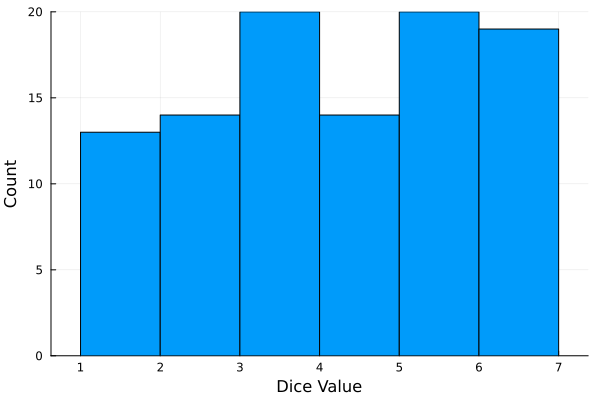

In [68]:
histogram(dice_rolls, legend=:false, bins=6)
ylabel!("Count")
xlabel!("Dice Value")

### Instructions

**Remember to**:

-   Evaluate all of your code cells, in order (using a `Run All`
    command). This will make sure all output is visible and that the
    code cells were evaluated in the correct order.
-   Tag each of the problems when you submit to Gradescope; a 10%
    penalty will be deducted if this is not done.

## Problem

A common engineering problem is to quantify flood risk, which is
typically computed by propagating a flood hazard distribution through a
*depth-damage function* relating flood depths to economic damages. A
reasonable depth-damage function for a house without a basement is a
bounded logistic function,
$$d(h) = \mathbb{1}_{h > 0} \frac{L}{1 + \exp(-k (h - h_0))},$$

where $d$ is the damage as a percent of total structure value, $h$ is
the water depth (relative to the house’s ground floor elevation) in m,
$\mathbb{1}_{x > 0}$ is the indicator function, $L$ is the maximum loss
in USD, $k$ is the slope of the depth-damage relationship, and $h_0$ is
the inflection point. We’ll assume $L=\$200,000$, $k=0.8$, and $h_0=3$.

For this problem, suppose that we have two different probability
distributions characterizing annual maxima flood depths:

1.  $h \sim LogNormal(1.2, 0.3)$;
2.  $h \sim GeneralizedExtremeValue(3, 0.9, -0.15)$.

Plot histograms of samples from these distributions and conduct a Monte
Carlo experiment for annual maximum flood damages using each. Answer the
following questions:

-   What are the Monte Carlo estimates of the expected value and the 99%
    quantile for the annual maximum damage the structure would suffer
    for each of these flood hazard distributions?
-   How did you decide on your sample size?
-   Why do you think the estimates differed or did not differ (you can
    also plot the depth-damage function to compare with the samples)?
-   How might you decide (based on getting additional information, if
    needed) which distribution is “better”?

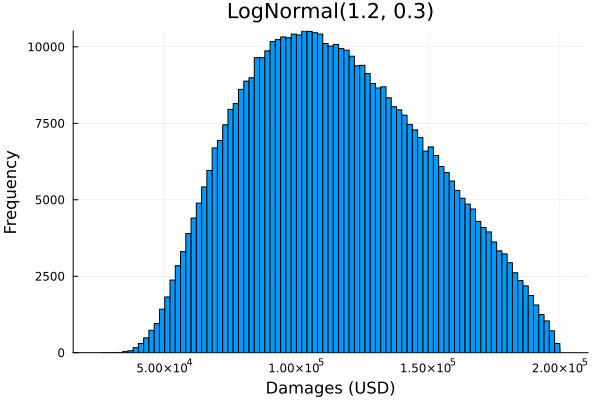

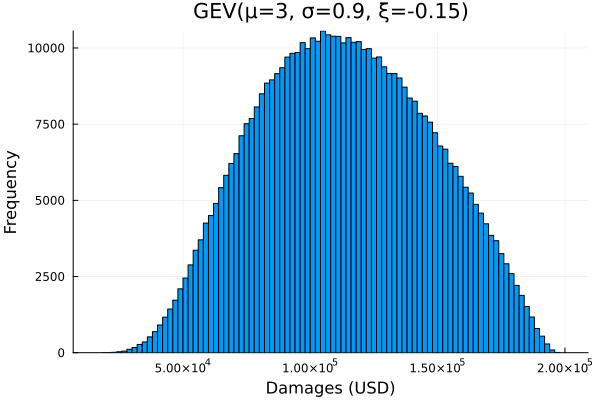

LogNormal mean damage = $115198.5 ± $48.42
95% CI for LogNormal = [$115103.59, $115293.4]
GEV mean damage = $113466.03 ± $47.63
95% CI for GEV = [$113372.67, $113559.4]

LogNormal 99th percentile = $189851.32
GEV 99th percentile = $183352.17


In [82]:
using Distributions, DataFrames, Random, StatsBase, Plots

L  = 200000 #max loss, USD
k  = 0.8 #slope
h0 = 3.0 #inflection point, m

Random.seed!(1)

#depth-damage function

function damage(h)
    if h > 0
        d = L / (1 + exp(-k * (h - h0)))
    else
        d = 0
    end
    return d
end

N = 500000

# Model 1: LogNormal(μ=1.2, σ=0.3)
ln_dist = LogNormal(1.2, 0.3)
ln_samples = rand(ln_dist, N)
ln_dmg = [damage(h) for h in ln_samples]

# Model 2: GeneraliedExtremeValue(μ=3, σ=0.9, ξ=-0.15)
gev_dist = GeneralizedExtremeValue(3, 0.9, -0.15)
gev_samples = rand(gev_dist, N)
gev_dmg = [damage(h) for h in gev_samples]

# histograms
h1 = histogram(ln_dmg, legend=false,  xlabel="Damages (USD)", ylabel = "Frequency", title="LogNormal(1.2, 0.3)")
display(h1)

h2 = histogram(gev_dmg, legend=false,  xlabel="Damages (USD)", ylabel = "Frequency", title="GEV(μ=3, σ=0.9, ξ=-0.15)")
display(h2)


N = length(ln_dmg)

# standard deviations
ln_std = std(ln_dmg)
gev_std = std(gev_dmg)

# Monte Carlo standard error using σ / √N
ln_se = ln_std / sqrt(N)
gev_se = gev_std / sqrt(N)

# means
ln_mean = mean(ln_dmg)
gev_mean = mean(gev_dmg)

# 99th percentile
ln_q99 = quantile(ln_dmg, 0.99)
gev_q99 = quantile(gev_dmg, 0.99)

# 95% confidence intervals
z = 1.96
ln_ci = (ln_mean - z*ln_se, ln_mean + z*ln_se)
gev_ci = (gev_mean - z*gev_se, gev_mean + z*gev_se)

println("LogNormal mean damage = \$$(round(ln_mean, digits=2)) ± \$$(round(ln_se, digits=2))")
println("95% CI for LogNormal = [\$$(round(ln_ci[1], digits=2)), \$$(round(ln_ci[2], digits=2))]")
println("GEV mean damage = \$$(round(gev_mean, digits=2)) ± \$$(round(gev_se, digits=2))")
println("95% CI for GEV = [\$$(round(gev_ci[1], digits=2)), \$$(round(gev_ci[2], digits=2))]")
println()
println("LogNormal 99th percentile = \$$(round(ln_q99, digits=2))")
println("GEV 99th percentile = \$$(round(gev_q99, digits=2))")





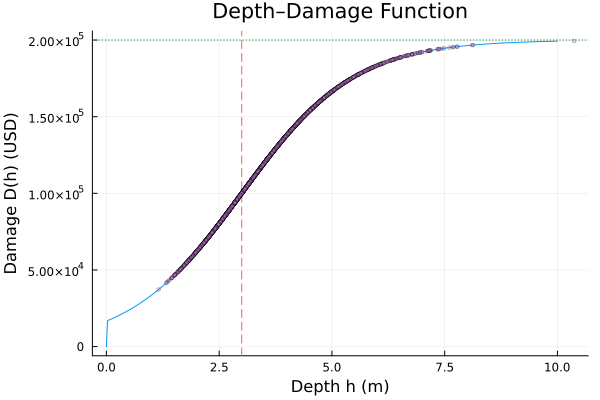

In [83]:
using Plots

# parameters
L  = 200_000.0
k  = 0.8
h0 = 3.0

# depth → damage
damage(h) = h > 0 ? L / (1 + exp(-k*(h - h0))) : 0.0

# grid and plot
hgrid = range(0, 10; length=400)
plot(hgrid, damage.(hgrid);
     xlabel="Depth h (m)", ylabel="Damage D(h) (USD)",
     title="Depth–Damage Function", legend=false)

# (optional) show inflection and cap
vline!([h0], ls=:dash)
hline!([L],  ls=:dot)

scatter!(ln_samples[1:4000], ln_dmg[1:4000]; ms=2, alpha=0.3)



**What are the Monte Carlo estimates of the expected value and the 99% quantile for the annual maximum damage the structure would suffer for each of these flood hazard distributions?**

For the LogNormal distribution, the Monte Carlo estimate of the expected value is $115198.5 and the 99% quantile is $189851.32.
For the GEV distribution, the Monte Carlo estimate of the expected value is $113466.03 and the 99% quantile is $183352.17.
I found these by first modeling the depth-damage function, then the distributions using a function, random numbers, and an N of 500,000. Finally, I plotted the distribution values for each model on histograms shown above.

**How did you decide on your sample size?**
   
We saw in class that decreasing Monte Carlo error by 10x requires 100x additional samples. With sample size N = 500,000 the Monte Carlo standard error, $SE = \frac{\sigma}{\sqrt{N}}$, was less than $200 for both distributions. That is less than 0.2% of the mean, meaning this is already a pretty good model. In addition, the 95% confidence intervals for both methods were very small too (les than 0.2% of the mean). Therefore, increasing the N would not really change the estimated mean by much and this is how I chose 500,000 as a solid sample size to yield good results.

**Why do you think the estimates differed or did not differ (you can also plot the depth-damage function to compare with the samples)?**
    
The models were pretty similar. They both neared maximum damages of $200,000 and are bell-shaped as shown above in the graphs. However, the LogNormal model has a little bit of a higher mean and 99th percentile damage than the GEV model. This makes sense because the graph shows that the LogNormal graph has a bit of a tail on the right-side.This means that it had a higher number of severe floods above the inflection point $h_0$. I plotted the depth-damage function to compare with the samples, too. The curve is clearly bounded at $200,000 so both models are just basically modeled at this maximum. I think that the LogNormal estimate is just a little higher because it has more probability around the inflection point where damages change the most and where the curve is steepest.

**How might you decide (based on getting additional information, if needed) which distribution is “better”?**

To decide which one is better it would be helpful to collect data of past flooding events. Similarly, we could collect more data of future flooding. This would allow us to fit both models and compare to what is actually happening. Whichever model fits the data closest would be the "better" distribution.


## References

Put any consulted sources here, including classmates you worked with/who
helped you.

I collaborated with Parker during class on Wednesday, asking questions and checking our work as we worked through the assignment.